# Week 6 and 7

This notebook uses the `triage_cleaned_v1.csv` dataset, which is a product of the `Week5_DataExploration.ipynb` notebook. It is used in this notebook to train and test 3 baseline models: a dummy classifier, a logistic regression model, and a decision tree model. The goal is to accurately predict the ESI (Emergency Severity Index) levels of ED patients.

## 1. Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, f1_score, recall_score,
)

pd.set_option("display.width", 120)
print("Libraries loaded. ✅")

Libraries loaded. ✅


In [4]:
df = pd.read_csv("triage_cleaned_v1.csv")
print("Dataset successfully loaded:", df.shape[0], "patients and", df.shape[1], "columns.")
df.head()

Dataset successfully loaded: 55121 patients and 226 columns.


,Unnamed: 0,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Prepare the features (X) and target (y)

### 2.1 Grouping of columns into categories for modelling purposes

In [5]:
TARGET = "esi"

# Vital-sign columns measured at the front door:
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]

# Who the patient is:
NUMERICAL_DEMOGRAPHICS = ["age"]

CATEGORICAL_DEMOGRAPHICS = ["gender", "ethnicity", "race", "lang", "religion", 
                            "maritalstatus", "employstatus", "insurance_status"]

# Administrative / arrival details:
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]

# OUTCOMES of the visit — known only AFTER triage, so they must never be model inputs:
LEAKAGE = ["disposition", "previousdispo"]

FEATURES = [c for c in df.columns if c != TARGET and c not in LEAKAGE + ADMIN]

In [6]:
X = df[FEATURES]
y = df[TARGET]

print("Number of features before one-hot encoding:", len(FEATURES))
print("Model will use features to predict:", TARGET)
print("First few features:", FEATURES[:10], "...")

Number of features before one-hot encoding: 218
Model will use features to predict: esi
First few features: ['Unnamed: 0', 'age', 'gender', 'ethnicity', 'race', 'lang', 'religion', 'maritalstatus', 'employstatus', 'insurance_status'] ...


### 2.2 One-hot encoding of categorical demographic features

Our models can only handle numerical data. Thus, our non-numerical data (categorical demographics) needs to be converted. We achieve this through one-hot encoding.

In [7]:
encoder = OneHotEncoder(
    handle_unknown="ignore", # prevents errors if the test set contains categories not seen during training.
    sparse_output=False # returns a regular NumPy array instead of a sparse matrix
)

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", encoder, CATEGORICAL_DEMOGRAPHICS)
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
)

In [9]:
X_processed = preprocessor.fit_transform(X)

In [10]:
feature_names = preprocessor.get_feature_names_out()

print("Number of features after one-hot encoding:", len(feature_names))
print("First few features:", feature_names[:10], "...")

Number of features after one-hot encoding: 263
First few features: ['gender_Female' 'gender_Male' 'ethnicity_Hispanic or Latino'
 'ethnicity_Non-Hispanic' 'ethnicity_Patient Refused' 'ethnicity_Unknown'
 'race_American Indian or Alaska Native' 'race_Asian'
 'race_Black or African American'
 'race_Native Hawaiian or Other Pacific Islander'] ...


### 2.3 Split into training and test sets

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, stratify=y, random_state=42)

print("Training patients:", X_train.shape[0])
print("Testing patients: ", X_test.shape[0])

Training patients: 44096
Testing patients:  11025


## 3. Baseline Models

### 3.1 Dummy Classifier

In [12]:
dummy = DummyClassifier(strategy="stratified", random_state=42)
dummy.fit(X_train, y_train)
print(round(dummy.score(X_test, y_test) * 100, 2), "% accuracy on the test set.")

37.54 % accuracy on the test set.


### 3.2 Logistic Regression

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)
logreg_score = logreg.score(X_test_scaled, y_test)
print(round(logreg_score * 100, 2), "% accuracy on the test set.")

67.99 % accuracy on the test set.


### 3.3 Decision Tree

In [14]:
tree = DecisionTreeClassifier(max_depth=15, random_state=42)
tree.fit(X_train, y_train)
print(round(tree.score(X_test, y_test) * 100, 2), "% accuracy on the test set.")

59.6 % accuracy on the test set.


The max_depth hyperparameter was selected by comparing model performance across several candidate values (5, 10, 15, and 20). Test accuracy increased substantially up to a depth of 15 (54.74% → 59.35%), but only marginally thereafter (59.45% at a depth of 20). Since the additional 0.10 percentage point improvement did not justify the increased model complexity and greater risk of overfitting, a maximum depth of 15 was chosen as the best trade-off between predictive performance and model complexity.

## 4. Model Evaluation

### 4.1 Accuracy, Precision, Recall, and F1

In [15]:
pred_dummy = dummy.predict(X_test)
print("Dummy Classifier Classification Report:\n", classification_report(y_test, pred_dummy))

Dummy Classifier Classification Report:
               precision    recall  f1-score   support

         1.0       0.00      0.00      0.00        16
         2.0       0.33      0.33      0.33      3585
         3.0       0.49      0.50      0.49      5402
         4.0       0.15      0.15      0.15      1779
         5.0       0.05      0.05      0.05       243

    accuracy                           0.38     11025
   macro avg       0.20      0.20      0.20     11025
weighted avg       0.37      0.38      0.37     11025



In [16]:
pred_logreg = logreg.predict(X_test_scaled)
print("Logistic Regression Classification Report:\n", classification_report(y_test, pred_logreg))

Logistic Regression Classification Report:
               precision    recall  f1-score   support

         1.0       0.40      0.25      0.31        16
         2.0       0.73      0.62      0.67      3585
         3.0       0.68      0.76      0.72      5402
         4.0       0.63      0.61      0.62      1779
         5.0       0.43      0.14      0.22       243

    accuracy                           0.68     11025
   macro avg       0.57      0.48      0.51     11025
weighted avg       0.68      0.68      0.67     11025



In [17]:
pred_tree = tree.predict(X_test)
print("Decision Tree Classification Report:\n", classification_report(y_test, pred_tree))

Decision Tree Classification Report:
               precision    recall  f1-score   support

         1.0       0.00      0.00      0.00        16
         2.0       0.73      0.46      0.57      3585
         3.0       0.56      0.88      0.68      5402
         4.0       0.65      0.10      0.18      1779
         5.0       0.00      0.00      0.00       243

    accuracy                           0.60     11025
   macro avg       0.39      0.29      0.28     11025
weighted avg       0.62      0.60      0.55     11025



c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

### 4.2 Confusion Matrix

In [18]:
Path("figs").mkdir(exist_ok=True)

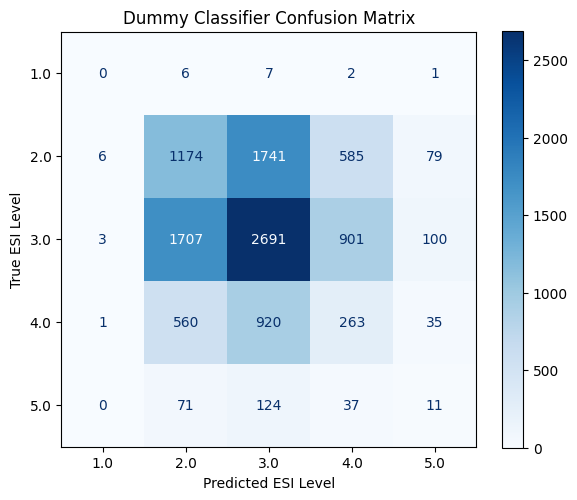

In [19]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_dummy, ax=ax, cmap=plt.cm.Blues)
ax.set_xlabel("Predicted ESI Level")
ax.set_ylabel("True ESI Level")
ax.set_title("Dummy Classifier Confusion Matrix")
plt.tight_layout()
plt.savefig("figs/dummy_classifier_confusion_matrix.png", dpi=150)
plt.show()

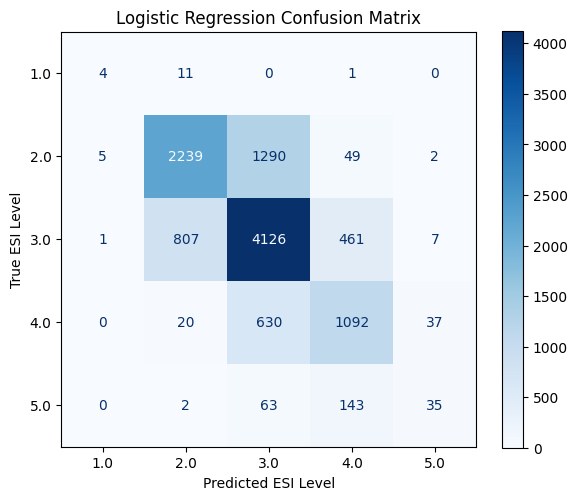

In [20]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_logreg, ax=ax, cmap=plt.cm.Blues)
ax.set_xlabel("Predicted ESI Level")
ax.set_ylabel("True ESI Level")
ax.set_title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.savefig("figs/logistic_regression_confusion_matrix.png", dpi=150)
plt.show()

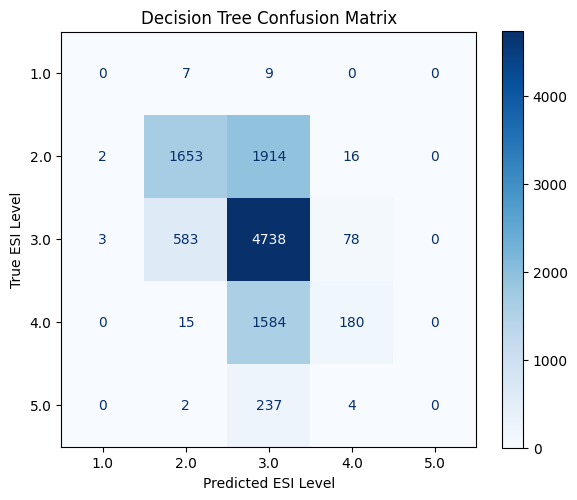

In [21]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_tree, ax=ax, cmap=plt.cm.Blues)
ax.set_xlabel("Predicted ESI Level")
ax.set_ylabel("True ESI Level")
ax.set_title("Decision Tree Confusion Matrix")
plt.tight_layout()
plt.savefig("figs/decision_tree_confusion_matrix.png", dpi=150)
plt.show()

### 4.3 Macro vs Weighted F1 Score

In [22]:
macro_f1 = f1_score(y_test, pred_dummy, average="macro")
weighted_f1 = f1_score(y_test, pred_dummy, average="weighted")
print("Dummy Classifier F1 Scores:")
print(f"Macro F1: {macro_f1:.3f}")
print(f"Weighted F1: {weighted_f1:.3f}")

Dummy Classifier F1 Scores:
Macro F1: 0.204
Weighted F1: 0.375


In [23]:
macro_f1 = f1_score(y_test, pred_logreg, average="macro")
weighted_f1 = f1_score(y_test, pred_logreg, average="weighted")
print("Logistic Regression F1 Scores:")
print(f"Macro F1: {macro_f1:.3f}")
print(f"Weighted F1: {weighted_f1:.3f}")

Logistic Regression F1 Scores:
Macro F1: 0.506
Weighted F1: 0.675


In [24]:
macro_f1 = f1_score(y_test, pred_tree, average="macro")
weighted_f1 = f1_score(y_test, pred_tree, average="weighted")
print("Decision Tree F1 Scores:")
print(f"Macro F1: {macro_f1:.3f}")
print(f"Weighted F1: {weighted_f1:.3f}")

Decision Tree F1 Scores:
Macro F1: 0.285
Weighted F1: 0.547


## 5. A More Complex Model: Random Forest

This section trains a more complex classifier — a `RandomForestClassifier` — to see whether it improves on the baseline models above. To keep the comparison fair (like-for-like), this section **reuses the exact same train/test split** created in Section 2.3 (`X_train`, `X_test`, `y_train`, `y_test`, built with `train_test_split(..., random_state=42)`); no new split is created here. A random seed (`random_state=42`) is also set explicitly on the model itself for reproducibility.

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

print("Libraries for Random Forest loaded. ✅")

Libraries for Random Forest loaded. ✅


### 5.1 Train the Random Forest on the reused train/test split

In [26]:
RANDOM_STATE = 42  # same seed used for the train/test split in Section 2.3

# NOTE: X_train / y_train / X_test / y_test are the SAME objects created in
# Section 2.3 above (train_test_split(..., test_size=0.2, stratify=y, random_state=42)).
# They are reused here unchanged so the Random Forest is evaluated on the
# identical test patients as the dummy, logistic regression, and decision
# tree baselines, making the comparison like-for-like.

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
print(round(rf.score(X_test, y_test) * 100, 2), "% accuracy on the test set.")

52.76 % accuracy on the test set.


In [27]:
pred_rf = rf.predict(X_test)
print("Random Forest Classification Report:\n", classification_report(y_test, pred_rf, digits=4))

Random Forest Classification Report:
               precision    recall  f1-score   support

         1.0     0.0000    0.0000    0.0000        16
         2.0     0.5710    0.7291    0.6405      3585
         3.0     0.7536    0.3545    0.4822      5402
         4.0     0.3524    0.6734    0.4626      1779
         5.0     0.1779    0.3704    0.2403       243

    accuracy                         0.5276     11025
   macro avg     0.3710    0.4255    0.3651     11025
weighted avg     0.6157    0.5276    0.5245     11025



c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

### 5.2 Accuracy, Precision, Recall, and F1 — reported per class

`classification_report` above already breaks precision, recall, and F1 down **per ESI class** rather than only giving one aggregate number. The cell below rebuilds those same per-class values into a small table (rounded to 4 decimal places) alongside the overall accuracy, so the numbers are easy to read and compare directly against the baseline models.

In [28]:
precision, recall, f1, support = precision_recall_fscore_support(y_test, pred_rf, labels=sorted(y_test.unique()))
rf_per_class = pd.DataFrame({
    "ESI level": sorted(y_test.unique()),
    "precision": precision.round(4),
    "recall": recall.round(4),
    "f1_score": f1.round(4),
    "support": support,
}).set_index("ESI level")

rf_accuracy = accuracy_score(y_test, pred_rf)
print(f"Random Forest overall accuracy: {rf_accuracy:.4f}")
print("\nRandom Forest per-class precision / recall / F1:")
rf_per_class

Random Forest overall accuracy: 0.5276

Random Forest per-class precision / recall / F1:


c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,precision,recall,f1_score,support
ESI level,,,,
1.0,0.0000,0.0000,0.0000,16
2.0,0.5710,0.7291,0.6405,3585
3.0,0.7536,0.3545,0.4822,5402
4.0,0.3524,0.6734,0.4626,1779
5.0,0.1779,0.3704,0.2403,243


### 5.3 Confusion Matrix

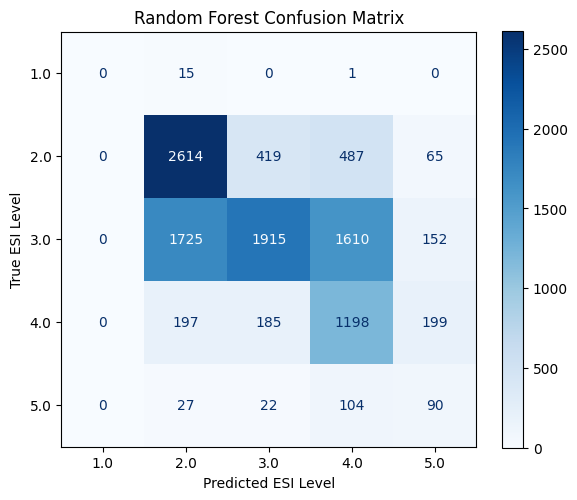

In [29]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_rf, ax=ax, cmap=plt.cm.Blues)
ax.set_xlabel("Predicted ESI Level")
ax.set_ylabel("True ESI Level")
ax.set_title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.savefig("figs/random_forest_confusion_matrix.png", dpi=150)
plt.show()

### 5.4 Macro vs Weighted F1 Score

In [30]:
macro_f1 = f1_score(y_test, pred_rf, average="macro")
weighted_f1 = f1_score(y_test, pred_rf, average="weighted")
print("Random Forest F1 Scores:")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")

Random Forest F1 Scores:
Macro F1: 0.3651
Weighted F1: 0.5245


### 5.5 Comparing the Random Forest to the Baselines

In [31]:
comparison = pd.DataFrame({
    "Accuracy": {
        "Dummy": accuracy_score(y_test, pred_dummy),
        "Logistic Regression": accuracy_score(y_test, pred_logreg),
        "Decision Tree": accuracy_score(y_test, pred_tree),
        "Random Forest": accuracy_score(y_test, pred_rf),
    },
    "Macro F1": {
        "Dummy": f1_score(y_test, pred_dummy, average="macro"),
        "Logistic Regression": f1_score(y_test, pred_logreg, average="macro"),
        "Decision Tree": f1_score(y_test, pred_tree, average="macro"),
        "Random Forest": f1_score(y_test, pred_rf, average="macro"),
    },
    "Weighted F1": {
        "Dummy": f1_score(y_test, pred_dummy, average="weighted"),
        "Logistic Regression": f1_score(y_test, pred_logreg, average="weighted"),
        "Decision Tree": f1_score(y_test, pred_tree, average="weighted"),
        "Random Forest": f1_score(y_test, pred_rf, average="weighted"),
    },
}).round(4)
comparison.sort_values("Macro F1", ascending=False)

,Accuracy,Macro F1,Weighted F1
Logistic Regression,0.6799,0.5064,0.6749
Random Forest,0.5276,0.3651,0.5245
Decision Tree,0.5960,0.2846,0.5466
Dummy,0.3754,0.2039,0.3746


## 6. Six-Axis Benchmarking: Training Time, Inference Time, and Interpretability

### 6.1 Training time and inference time (per prediction)

This section times the baseline (Logistic Regression) and the complex model (Random Forest) on the **same reused train/test split** from Section 2.3.

To get a clean measurement, each model is re-fit once from a fresh (untrained) instance with the identical hyperparameters and `random_state` used earlier, so the timing reflects only the `fit()` / `predict()` calls and not any side effects from earlier cells. This does not change the split, the seed, or the predictions already used for the accuracy/F1 metrics above — `logreg`, `rf`, `pred_logreg`, and `pred_rf` are left untouched.

Inference time is reported **per prediction** (total predict time divided by the number of test patients), since that is the cost that recurs for every patient in a live ED, not just once at training.

In [32]:
import time

# --- Logistic Regression: training time ---
t0 = time.perf_counter()
logreg_timed = LogisticRegression(max_iter=1000, random_state=42)
logreg_timed.fit(X_train_scaled, y_train)
logreg_train_time = time.perf_counter() - t0

# --- Logistic Regression: inference time (per prediction) ---
t0 = time.perf_counter()
_ = logreg_timed.predict(X_test_scaled)
logreg_infer_ms = (time.perf_counter() - t0) / len(X_test_scaled) * 1000

print(f"Logistic Regression training time:  {logreg_train_time:.4f} s")
print(f"Logistic Regression inference time: {logreg_infer_ms:.5f} ms per prediction")

Logistic Regression training time:  35.5007 s
Logistic Regression inference time: 0.00157 ms per prediction


In [33]:
# --- Random Forest: training time ---
t0 = time.perf_counter()
rf_timed = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    class_weight="balanced",
    random_state=RANDOM_STATE,  # same seed as the split (Section 2.3) and the RF above (Section 5.1)
    n_jobs=-1,
)
rf_timed.fit(X_train, y_train)
rf_train_time = time.perf_counter() - t0

# --- Random Forest: inference time (per prediction) ---
t0 = time.perf_counter()
_ = rf_timed.predict(X_test)
rf_infer_ms = (time.perf_counter() - t0) / len(X_test) * 1000

print(f"Random Forest training time:  {rf_train_time:.4f} s")
print(f"Random Forest inference time: {rf_infer_ms:.5f} ms per prediction")

Random Forest training time:  20.5167 s
Random Forest inference time: 0.03861 ms per prediction


### 6.2 Interpretability: can a single prediction be explained in under a minute?

- **Logistic Regression** — coefficients can be read directly: each feature has one weight per class, so the sign and size of that weight tells you exactly how it pushed a given prediction. This is a **high**-interpretability, roughly one-minute explanation.
- **Random Forest** — `feature_importances_` gives an aggregate ranking of which features matter *on average* across all 300 trees, but it does **not** explain any single patient's prediction — there is no one path to trace, and the 300 trees don't agree on a single story. This is **medium** interpretability: useful for understanding the model in general, but not a per-patient, under-a-minute explanation. A true per-prediction explanation for the Random Forest would require a method like **SHAP**, which is not computed in this notebook.

In [34]:
# Logistic Regression: coefficients can be read directly (high interpretability)
coefs = pd.DataFrame(logreg.coef_, columns=feature_names, index=logreg.classes_)
mean_abs_coef = coefs.abs().mean(axis=0).sort_values(ascending=False)

print("Logistic Regression - top 5 features by mean |coefficient| across classes:")
print(mean_abs_coef.head(5))

Logistic Regression - top 5 features by mean |coefficient| across classes:
cc_abdominalpain          0.748511
cc_chestpain              0.588976
cc_shortnessofbreath      0.433266
triage_vital_o2_device    0.362910
cc_emesis                 0.336257
dtype: float64


In [35]:
# Random Forest: feature importances (medium interpretability - aggregate only, not per-patient)
rf_importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)

print("Random Forest - top 5 features by importance (aggregate across all trees, not per-patient):")
print(rf_importances.head(5))

Random Forest - top 5 features by importance (aggregate across all trees, not per-patient):
cc_strokealert      0.079558
triage_vital_sbp    0.067342
age                 0.059186
triage_vital_dbp    0.055683
triage_vital_hr     0.046164
dtype: float64


### 6.3 Updated comparison table: all six quantitative axes + interpretability

In [36]:
benchmark_table = pd.DataFrame({
    "Accuracy":        {"Logistic Regression": accuracy_score(y_test, pred_logreg),
                         "Random Forest":       accuracy_score(y_test, pred_rf)},
    "Precision (macro)": {"Logistic Regression": precision_recall_fscore_support(y_test, pred_logreg, average="macro")[0],
                           "Random Forest":       precision_recall_fscore_support(y_test, pred_rf, average="macro")[0]},
    "Recall (macro)":    {"Logistic Regression": precision_recall_fscore_support(y_test, pred_logreg, average="macro")[1],
                           "Random Forest":       precision_recall_fscore_support(y_test, pred_rf, average="macro")[1]},
    "F1 (macro)":        {"Logistic Regression": f1_score(y_test, pred_logreg, average="macro"),
                           "Random Forest":       f1_score(y_test, pred_rf, average="macro")},
    "Training time (s)": {"Logistic Regression": logreg_train_time,
                           "Random Forest":       rf_train_time},
    "Inference time (ms/pred)": {"Logistic Regression": logreg_infer_ms,
                                  "Random Forest":       rf_infer_ms},
    "Interpretability":  {"Logistic Regression": "High (coefficients, <1 min)",
                           "Random Forest":       "Medium (feature importances only, no per-patient story)"},
}).round(4)

benchmark_table

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Accuracy,Precision (macro),Recall (macro),F1 (macro),Training time (s),Inference time (ms/pred),Interpretability
Logistic Regression,0.6799,0.572,0.4792,0.5064,35.5007,0.0016,"High (coefficients, <1 min)"
Random Forest,0.5276,0.371,0.4255,0.3651,20.5167,0.0386,"Medium (feature importances only, no per-patie..."
